Analiz verisi okundu.
Satır sayısı: 300


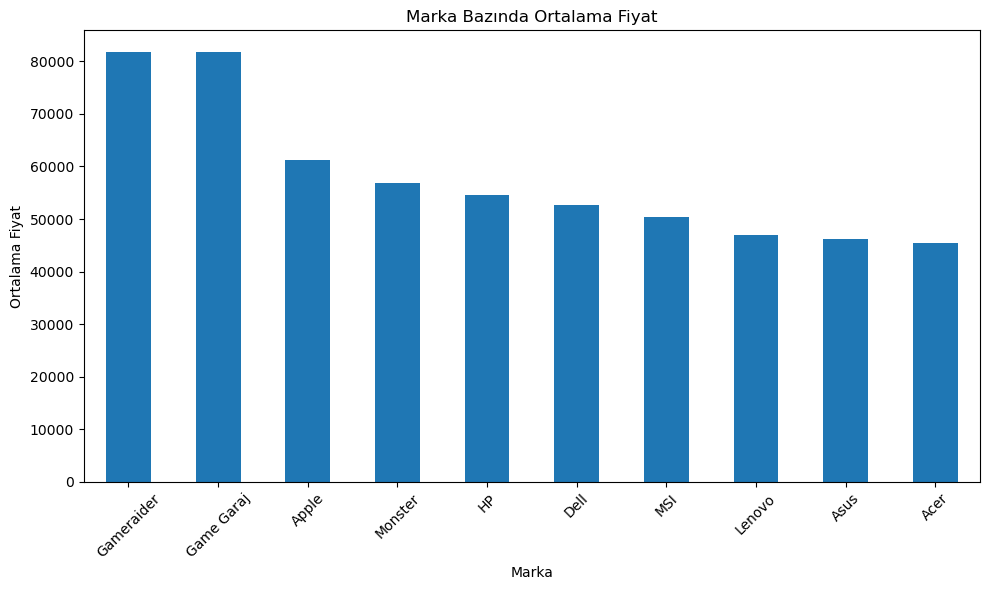

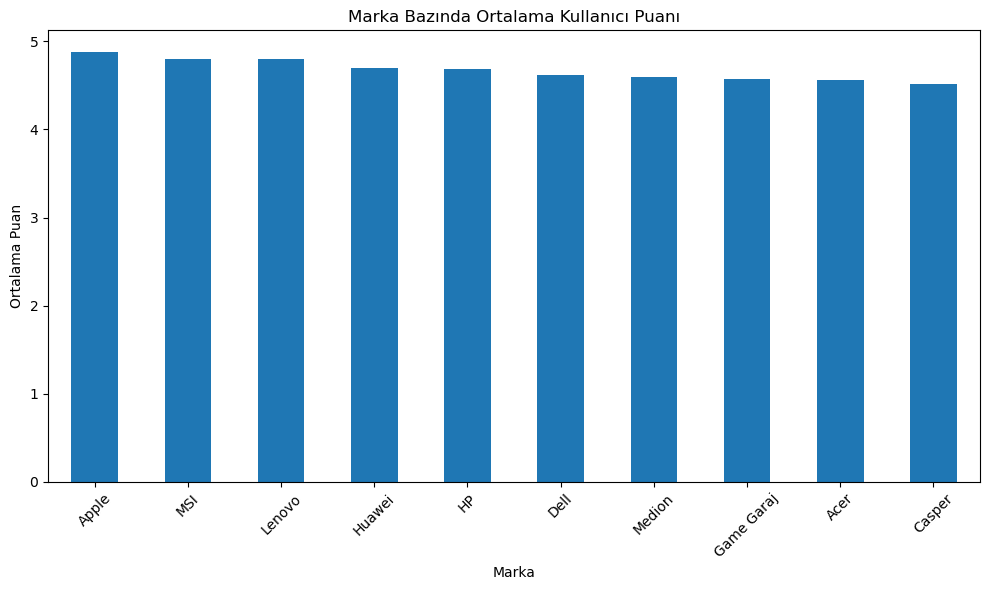

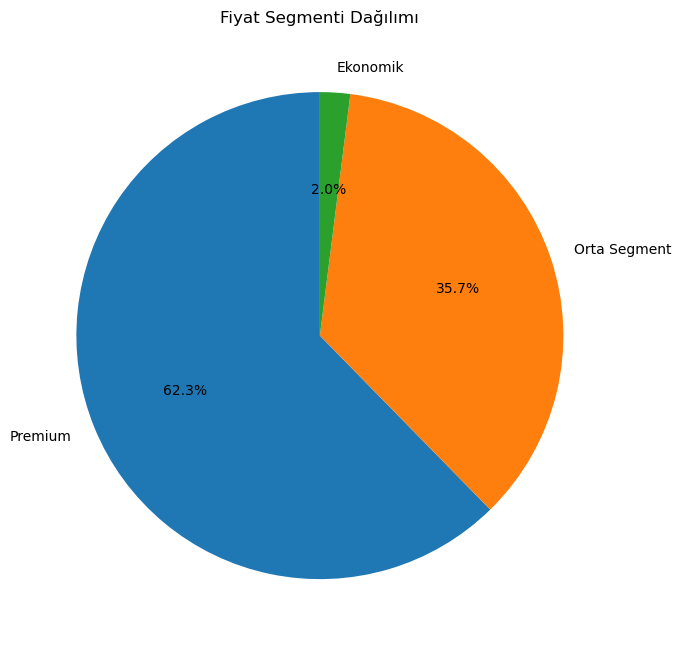

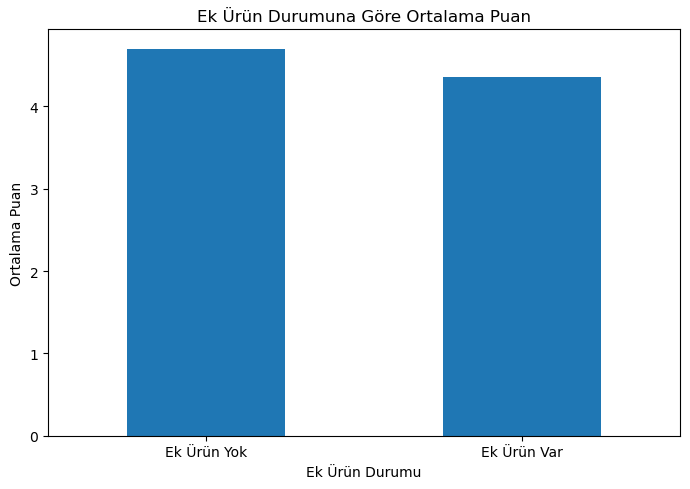

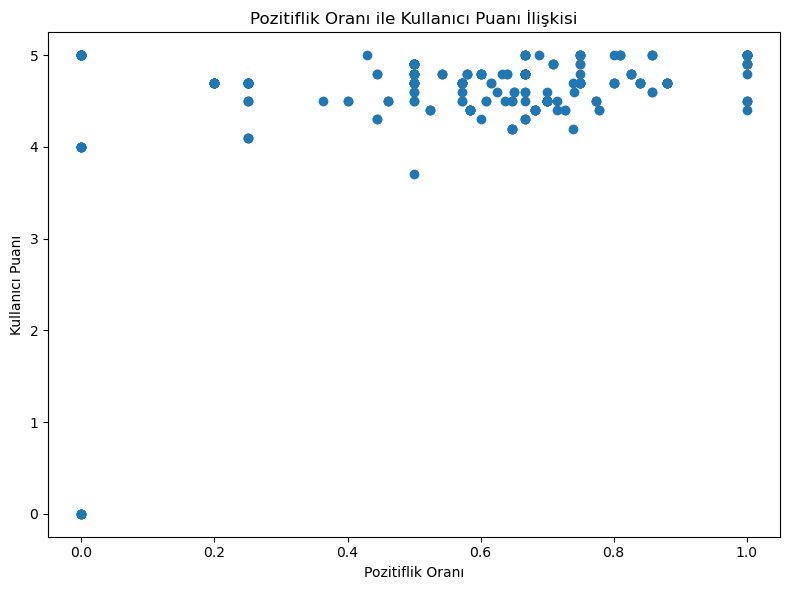

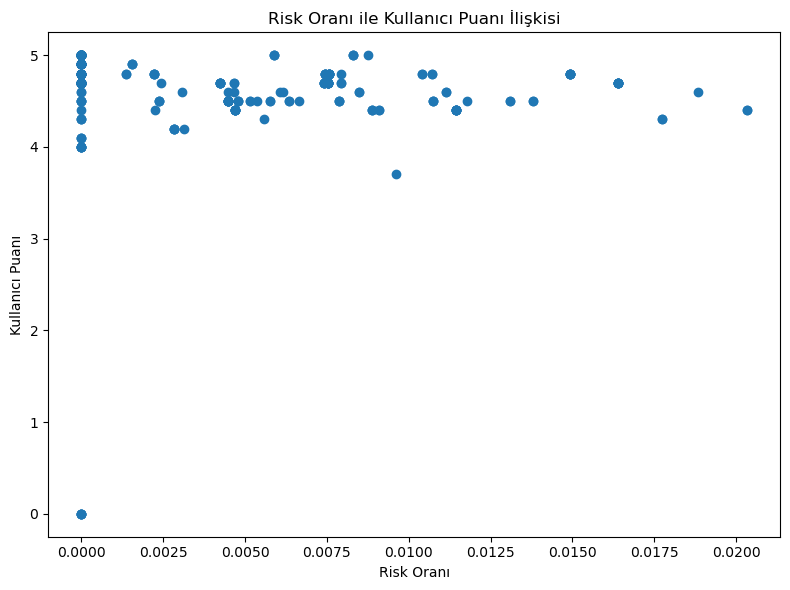


Grafikler oluşturuldu.
Klasör: grafikler
Marka özet dosyası oluşturuldu: marka_ozet_analizi.xlsx


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==============================
# DOSYA AYARLARI
# ==============================

GIRIS_DOSYASI = "analiz_verisi.xlsx"
CIKTI_KLASORU = "grafikler"

os.makedirs(CIKTI_KLASORU, exist_ok=True)

df = pd.read_excel(GIRIS_DOSYASI)

print("Analiz verisi okundu.")
print("Satır sayısı:", len(df))


# ==============================
# 1. MARKA BAZINDA ORTALAMA FİYAT
# ==============================

marka_fiyat = (
    df.groupby("marka")["fiyat_sayisal"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
marka_fiyat.plot(kind="bar")
plt.title("Marka Bazında Ortalama Fiyat")
plt.xlabel("Marka")
plt.ylabel("Ortalama Fiyat")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{CIKTI_KLASORU}/marka_ortalama_fiyat.png", dpi=300)
plt.show()


# ==============================
# 2. MARKA BAZINDA ORTALAMA PUAN
# ==============================

marka_puan = (
    df.groupby("marka")["puan_sayisal"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
marka_puan.plot(kind="bar")
plt.title("Marka Bazında Ortalama Kullanıcı Puanı")
plt.xlabel("Marka")
plt.ylabel("Ortalama Puan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{CIKTI_KLASORU}/marka_ortalama_puan.png", dpi=300)
plt.show()


# ==============================
# 3. FİYAT SEGMENTİ DAĞILIMI
# ==============================

segment_dagilimi = df["fiyat_segmenti"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    segment_dagilimi.values,
    labels=segment_dagilimi.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Fiyat Segmenti Dağılımı")
plt.tight_layout()
plt.savefig(f"{CIKTI_KLASORU}/fiyat_segmenti_dagilimi.png", dpi=300)
plt.show()


# ==============================
# 4. EK ÜRÜN VAR/YOK PUAN KARŞILAŞTIRMASI
# ==============================

ek_urun_puan = df.groupby("ek_urun_var")["puan_sayisal"].mean()
ek_urun_puan.index = ["Ek Ürün Yok", "Ek Ürün Var"]

plt.figure(figsize=(7, 5))
ek_urun_puan.plot(kind="bar")
plt.title("Ek Ürün Durumuna Göre Ortalama Puan")
plt.xlabel("Ek Ürün Durumu")
plt.ylabel("Ortalama Puan")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{CIKTI_KLASORU}/ek_urun_puan_karsilastirma.png", dpi=300)
plt.show()


# ==============================
# 5. POZİTİFLİK ORANI - PUAN İLİŞKİSİ
# ==============================

plt.figure(figsize=(8, 6))
plt.scatter(df["pozitiflik_orani"], df["puan_sayisal"])
plt.title("Pozitiflik Oranı ile Kullanıcı Puanı İlişkisi")
plt.xlabel("Pozitiflik Oranı")
plt.ylabel("Kullanıcı Puanı")
plt.tight_layout()
plt.savefig(f"{CIKTI_KLASORU}/pozitiflik_puan_iliskisi.png", dpi=300)
plt.show()


# ==============================
# 6. RİSK ORANI - PUAN İLİŞKİSİ
# ==============================

plt.figure(figsize=(8, 6))
plt.scatter(df["risk_orani"], df["puan_sayisal"])
plt.title("Risk Oranı ile Kullanıcı Puanı İlişkisi")
plt.xlabel("Risk Oranı")
plt.ylabel("Kullanıcı Puanı")
plt.tight_layout()
plt.savefig(f"{CIKTI_KLASORU}/risk_puan_iliskisi.png", dpi=300)
plt.show()


# ==============================
# ÖZET TABLOLAR
# ==============================

ozet_marka = df.groupby("marka").agg(
    urun_sayisi=("ürün_adı", "count"),
    ortalama_fiyat=("fiyat_sayisal", "mean"),
    ortalama_puan=("puan_sayisal", "mean"),
    ortalama_pozitiflik=("pozitiflik_orani", "mean"),
    ortalama_risk=("risk_orani", "mean")
).reset_index()

ozet_marka.to_excel("marka_ozet_analizi.xlsx", index=False)

print("\nGrafikler oluşturuldu.")
print("Klasör:", CIKTI_KLASORU)
print("Marka özet dosyası oluşturuldu: marka_ozet_analizi.xlsx")